# Task 8-2: DCGAN vs. MLP-GAN — Flowers Dataset

**TIES 4911 (2026)**

Based on: https://www.tensorflow.org/tutorials/generative/dcgan

**Dataset:** `tf_flowers` — 5 flower classes, resized to **64×64×3**.

**Goal:**
1. Implement the original **DCGAN** (Deep Convolutional GAN) from the TF tutorial
2. Convert it to a **MLP-GAN** by replacing all convolutional layers with fully-connected (Dense) layers
3. Train both on the flowers dataset and **compare generated image quality**

> **Note:** The MLP-GAN is NOT a separate downloaded implementation — it is directly derived from the DCGAN code by replacing Conv2D/Conv2DTranspose layers with Dense layers, as required by the task.

In [1]:
!pip install tensorflow-datasets keras-cv -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 42.2 MB/s eta 0:00:00


## 1. Imports & Setup

In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers
from IPython import display

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

tf.random.set_seed(42)
np.random.seed(42)

# Hyperparameters — tuned for fast CPU training
IMAGE_SIZE = 32     # reduced from 64 → 4x fewer pixels per image
CHANNELS = 3
NOISE_DIM = 100
BATCH_SIZE = 64     # larger batches → fewer steps per epoch
EPOCHS = 30         # reduced from 100 → enough to see DCGAN vs MLP difference
NUM_EXAMPLES = 16

TensorFlow version: 2.20.0
GPU available: []


## 2. Dataset Preparation

In [3]:
def preprocess_gan(image, label):
    """Resize and normalize to [-1, 1] (standard for GANs with tanh output)."""
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
    image = tf.cast(image, tf.float32)
    image = (image / 127.5) - 1.0  # [0, 255] -> [-1, 1]
    return image

ds_train, _ = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True
)

train_dataset = (
    ds_train
    .map(preprocess_gan, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(3000)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

# Fixed noise vectors for consistent visualization
seed_noise = tf.random.normal([NUM_EXAMPLES, NOISE_DIM], seed=42)

print(f'Dataset ready. Batches per epoch: {len(train_dataset)}')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.F91JVY_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Dataset ready. Batches per epoch: 45


## 3. DCGAN — Deep Convolutional GAN

Architecture follows the TF tutorial with adaptations for **64×64 color images**:

| Component | Layers |
|---|---|
| Generator | Dense → Reshape → 3× Conv2DTranspose → Conv2DTranspose (Tanh) |
| Discriminator | 3× Conv2D → Flatten → Dense (Sigmoid) |

All intermediate activations use **BatchNorm + LeakyReLU**.

In [4]:
# ─────────────────────────────────────────────
#  DCGAN Generator  (32×32 output)
# ─────────────────────────────────────────────
def make_dcgan_generator():
    model = keras.Sequential(name='DCGAN_Generator')

    # Project and reshape: 4×4 spatial start
    model.add(layers.Dense(4 * 4 * 128, use_bias=False, input_shape=(NOISE_DIM,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Reshape((4, 4, 128)))       # (4, 4, 128)

    # 4 → 8
    model.add(layers.Conv2DTranspose(64, 4, strides=2, padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))             # (8, 8, 64)

    # 8 → 16
    model.add(layers.Conv2DTranspose(32, 4, strides=2, padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))             # (16, 16, 32)

    # 16 → 32
    model.add(layers.Conv2DTranspose(CHANNELS, 4, strides=2, padding='same',
                                     use_bias=False, activation='tanh'))  # (32, 32, 3)

    assert model.output_shape == (None, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
    return model


# ─────────────────────────────────────────────
#  DCGAN Discriminator
# ─────────────────────────────────────────────
def make_dcgan_discriminator():
    model = keras.Sequential(name='DCGAN_Discriminator')

    model.add(layers.Conv2D(32, 4, strides=2, padding='same',
                            input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))               # (16, 16, 32)

    model.add(layers.Conv2D(64, 4, strides=2, padding='same'))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))               # (8, 8, 64)

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model


dcgan_generator = make_dcgan_generator()
dcgan_discriminator = make_dcgan_discriminator()
dcgan_generator.summary()
dcgan_discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "DCGAN_Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2048)           │       204,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 64)       │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 32)     │        32,768 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 3)      │         1,536 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 378,752 (1.44 MB)

 Trainable params: 374,464 (1.43 MB)

...

Model: "DCGAN_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,497 (150.38 KB)

 Trainable params: 38,497 (150.38 KB)

 Non-trainable params: 0 (0.00 B)

## 4. MLP-GAN — Fully-Connected GAN

**Modified directly from the DCGAN code** by replacing:
- `Conv2DTranspose` → `Dense` in the Generator
- `Conv2D` → `Dense` in the Discriminator
- Removed spatial BatchNorm (replaced with regular BatchNorm)
- Added `Reshape` / `Flatten` to bridge flat → image spaces

| Component | Layers |
|---|---|
| Generator | Dense(256) → Dense(512) → Dense(1024) → Dense(64×64×3) → Reshape → Tanh |
| Discriminator | Flatten → Dense(512) → Dense(256) → Dense(128) → Dense(1) |

In [5]:
# ─────────────────────────────────────────────
#  MLP-GAN Generator  (derived from DCGAN by replacing Conv2DTranspose → Dense)
# ─────────────────────────────────────────────
def make_mlp_generator():
    model = keras.Sequential(name='MLP_Generator')

    # Was: Dense → BatchNorm → Reshape
    model.add(layers.Dense(128, use_bias=False, input_shape=(NOISE_DIM,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))

    # Was: Conv2DTranspose(64) → now Dense(256)
    model.add(layers.Dense(256, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))

    # Was: Conv2DTranspose(32) → now Dense(512)
    model.add(layers.Dense(512, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))

    # Was: Conv2DTranspose(CHANNELS, tanh) → now Dense(flat) → Reshape
    model.add(layers.Dense(IMAGE_SIZE * IMAGE_SIZE * CHANNELS, use_bias=False))
    model.add(layers.Reshape((IMAGE_SIZE, IMAGE_SIZE, CHANNELS)))
    model.add(layers.Activation('tanh'))

    assert model.output_shape == (None, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
    return model


# ─────────────────────────────────────────────
#  MLP-GAN Discriminator  (derived from DCGAN by replacing Conv2D → Dense)
# ─────────────────────────────────────────────
def make_mlp_discriminator():
    model = keras.Sequential(name='MLP_Discriminator')

    # Was: Conv2D(32) → now Flatten + Dense(256)
    model.add(layers.Flatten(input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)))
    model.add(layers.Dense(256))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    # Was: Conv2D(64) → now Dense(128)
    model.add(layers.Dense(128))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    # Was: Flatten → Dense(1)
    model.add(layers.Dense(1))

    return model


mlp_generator = make_mlp_generator()
mlp_discriminator = make_mlp_discriminator()
mlp_generator.summary()
mlp_discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "MLP_Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │        12,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3072)           │     1,572,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 3)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,753,088 (6.69 MB)

 Trainable params: 1,751,296 (6.68 MB)

...

Model: "MLP_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 819,713 (3.13 MB)

 Trainable params: 819,713 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Loss Functions & Optimizers

Standard GAN losses (from the TF tutorial):

- **Discriminator loss** = cross-entropy(real=1) + cross-entropy(fake=0)
- **Generator loss** = cross-entropy(fake treated as real=1)

In [6]:
cross_entropy = keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# Plain Adam — works with Keras 3 (no legacy needed when @tf.function is removed)
dcgan_gen_optimizer  = keras.optimizers.Adam(2e-4, beta_1=0.5)
dcgan_disc_optimizer = keras.optimizers.Adam(2e-4, beta_1=0.5)
mlp_gen_optimizer    = keras.optimizers.Adam(2e-4, beta_1=0.5)
mlp_disc_optimizer   = keras.optimizers.Adam(2e-4, beta_1=0.5)

print('Loss functions and optimizers created.')

Loss functions and optimizers created.


## 6. Training Step

In [7]:
# @tf.function removed — incompatible with Keras 3 Adam optimizer
def train_step(images, generator, discriminator, gen_optimizer, disc_optimizer):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss  = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gen_grads  = gen_tape.gradient(gen_loss,  generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gen_grads,  generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

    return gen_loss, disc_loss


def save_images(generator, noise, filename, title):
    predictions = generator(noise, training=False)
    predictions = (predictions + 1.0) / 2.0  # [-1, 1] -> [0, 1]

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(predictions[i].numpy())
        ax.axis('off')
    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=100, bbox_inches='tight')
    plt.show()


def train(generator, discriminator, gen_opt, disc_opt, label, epochs=EPOCHS):
    gen_losses, disc_losses = [], []

    print(f'\n=== Training {label} for {epochs} epochs ===')
    start = time.time()

    for epoch in range(1, epochs + 1):
        ep_gen_loss, ep_disc_loss = [], []
        for images in train_dataset:
            g_loss, d_loss = train_step(images, generator, discriminator, gen_opt, disc_opt)
            ep_gen_loss.append(float(g_loss))
            ep_disc_loss.append(float(d_loss))

        gen_losses.append(np.mean(ep_gen_loss))
        disc_losses.append(np.mean(ep_disc_loss))

        if epoch % 10 == 0 or epoch == 1:
            elapsed = time.time() - start
            print(f'Epoch {epoch:3d}/{epochs} | G Loss: {gen_losses[-1]:.4f} | '
                  f'D Loss: {disc_losses[-1]:.4f} | Time: {elapsed:.1f}s')

    print(f'{label} training complete in {time.time() - start:.1f}s')
    return gen_losses, disc_losses

## 7. Train DCGAN


=== Training DCGAN for 30 epochs ===
Epoch   1/30 | G Loss: 0.5913 | D Loss: 1.2632 | Time: 41.0s
Epoch  10/30 | G Loss: 0.8591 | D Loss: 1.3416 | Time: 261.2s
Epoch  20/30 | G Loss: 0.7728 | D Loss: 1.3390 | Time: 529.4s
Epoch  30/30 | G Loss: 0.7031 | D Loss: 1.3913 | Time: 770.2s
DCGAN training complete in 770.2s


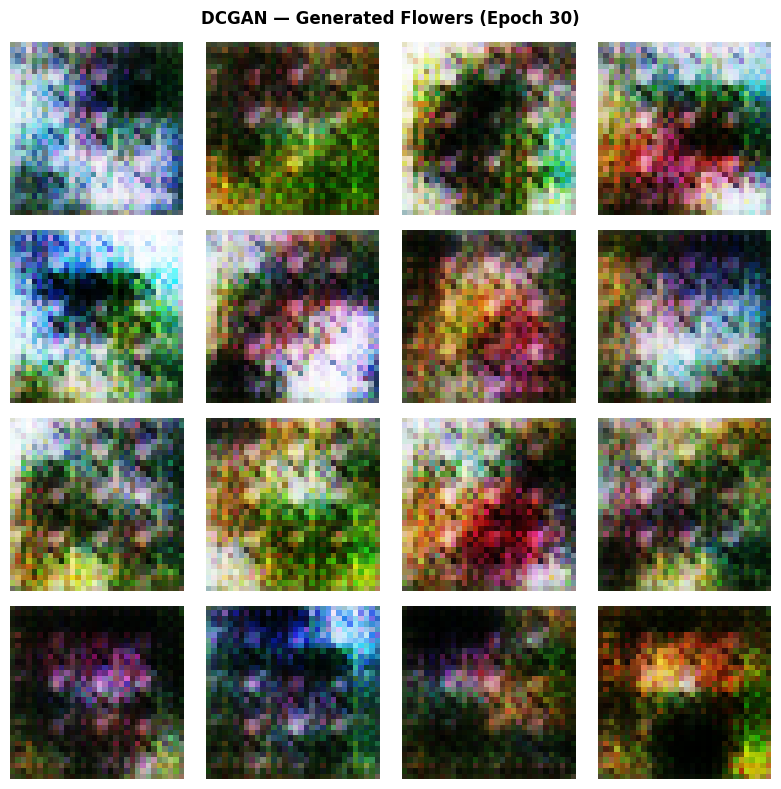

In [8]:
dcgan_gen_losses, dcgan_disc_losses = train(
    dcgan_generator, dcgan_discriminator,
    dcgan_gen_optimizer, dcgan_disc_optimizer,
    label='DCGAN'
)

save_images(dcgan_generator, seed_noise,
            'dcgan_final_generated.png',
            f'DCGAN — Generated Flowers (Epoch {EPOCHS})')

## 8. Train MLP-GAN


=== Training MLP-GAN for 30 epochs ===
Epoch   1/30 | G Loss: 0.4352 | D Loss: 1.4946 | Time: 12.7s
Epoch  10/30 | G Loss: 1.5740 | D Loss: 0.8142 | Time: 128.8s
Epoch  20/30 | G Loss: 1.4384 | D Loss: 0.9078 | Time: 256.1s
Epoch  30/30 | G Loss: 1.4840 | D Loss: 0.9751 | Time: 383.2s
MLP-GAN training complete in 383.2s


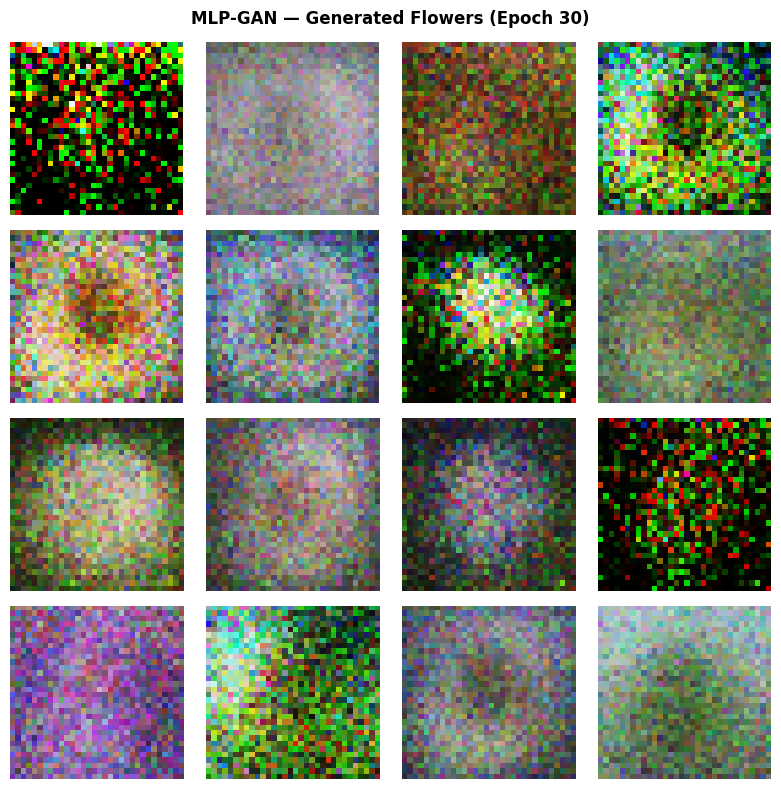

In [9]:
mlp_gen_losses, mlp_disc_losses = train(
    mlp_generator, mlp_discriminator,
    mlp_gen_optimizer, mlp_disc_optimizer,
    label='MLP-GAN'
)

save_images(mlp_generator, seed_noise,
            'mlpgan_final_generated.png',
            f'MLP-GAN — Generated Flowers (Epoch {EPOCHS})')

## 9. Loss Curves Comparison

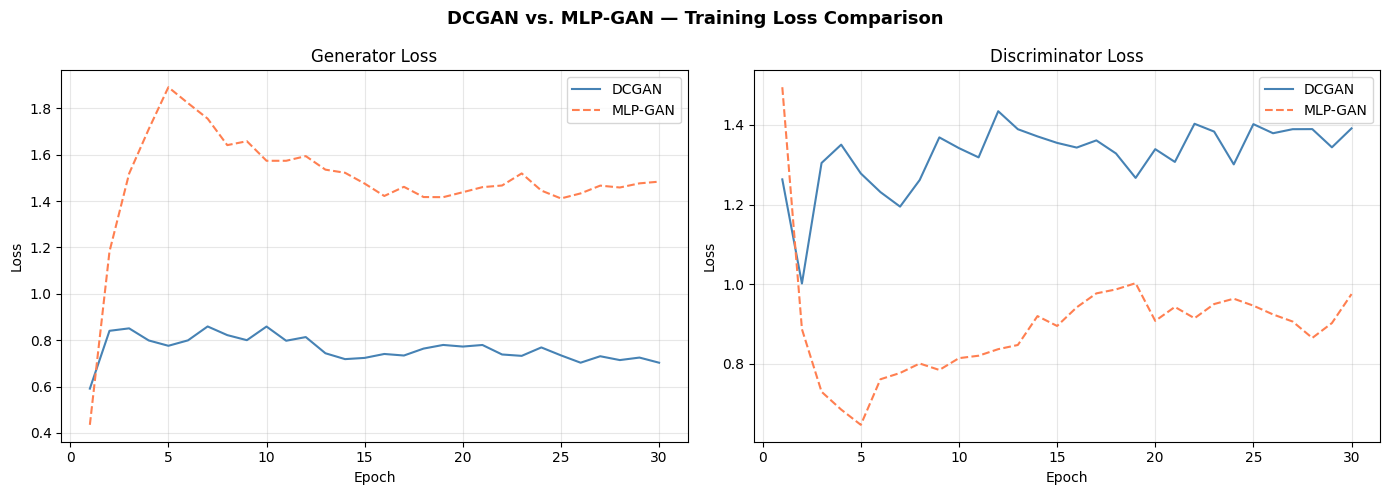

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, EPOCHS + 1)

# Generator losses
axes[0].plot(epochs_range, dcgan_gen_losses, label='DCGAN', color='steelblue')
axes[0].plot(epochs_range, mlp_gen_losses, label='MLP-GAN', color='coral', linestyle='--')
axes[0].set_title('Generator Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Discriminator losses
axes[1].plot(epochs_range, dcgan_disc_losses, label='DCGAN', color='steelblue')
axes[1].plot(epochs_range, mlp_disc_losses, label='MLP-GAN', color='coral', linestyle='--')
axes[1].set_title('Discriminator Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('DCGAN vs. MLP-GAN — Training Loss Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gan_loss_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 10. Side-by-Side Image Comparison

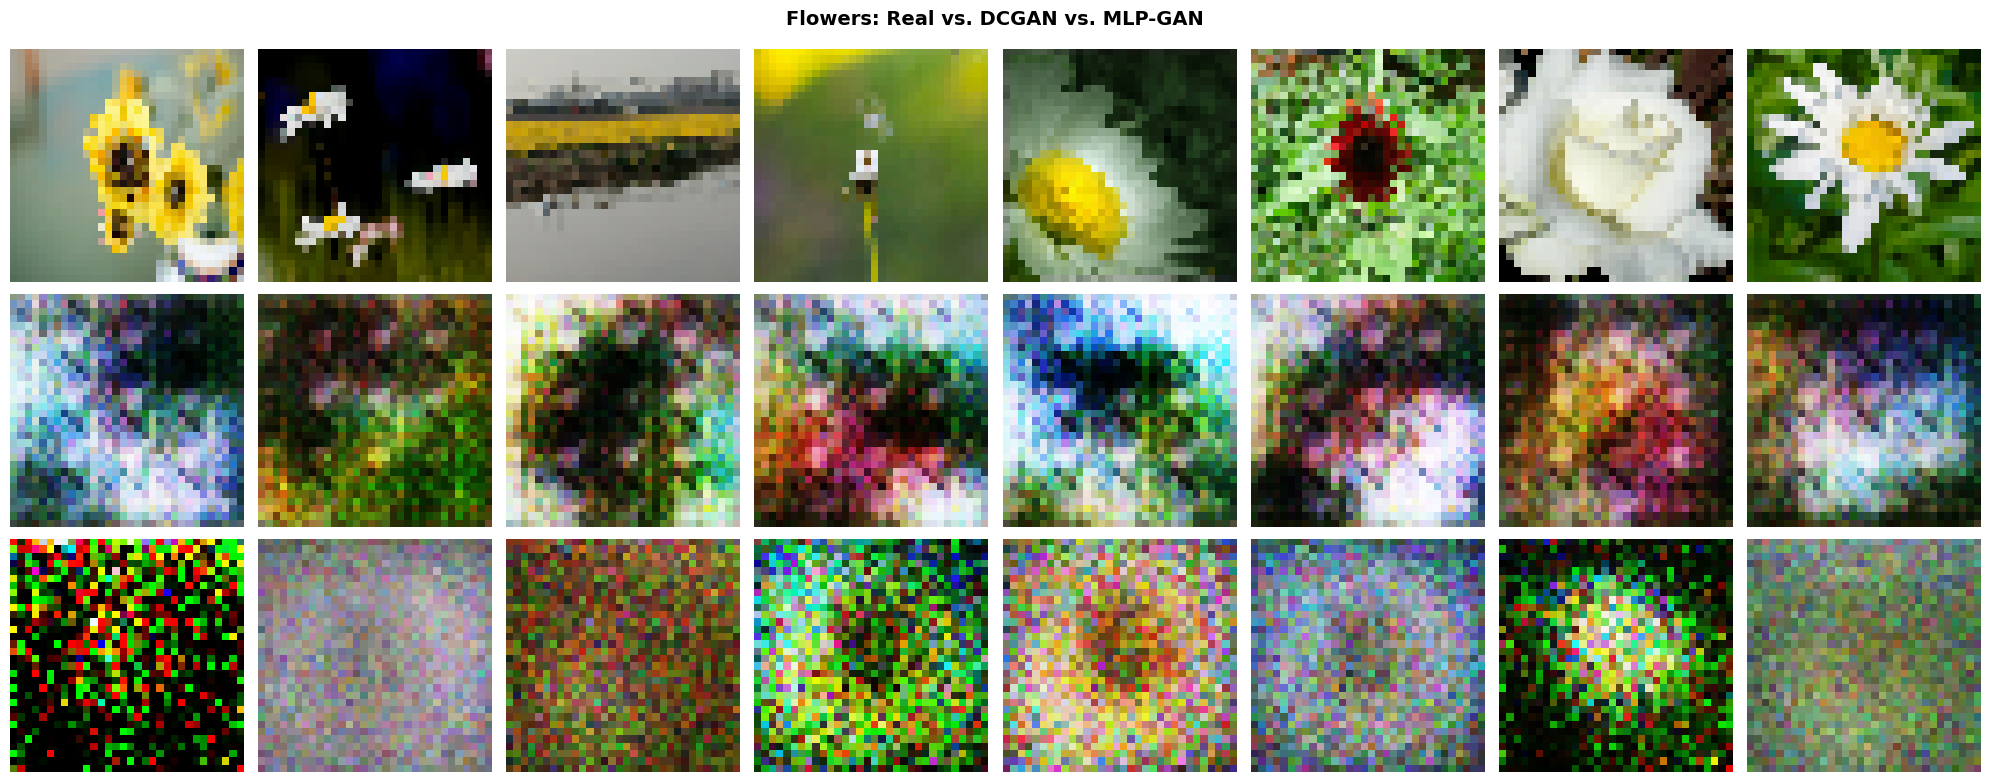

In [11]:
dcgan_images = (dcgan_generator(seed_noise[:8], training=False) + 1.0) / 2.0
mlp_images   = (mlp_generator(seed_noise[:8], training=False) + 1.0) / 2.0

fig, axes = plt.subplots(3, 8, figsize=(20, 8))

# Row 0: real samples
real_batch = next(iter(train_dataset))[:8]
real_batch_viz = (real_batch + 1.0) / 2.0

for i in range(8):
    axes[0, i].imshow(real_batch_viz[i].numpy())
    axes[0, i].axis('off')
    axes[1, i].imshow(dcgan_images[i].numpy())
    axes[1, i].axis('off')
    axes[2, i].imshow(mlp_images[i].numpy())
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Real', fontsize=12, rotation=0, labelpad=50, va='center')
axes[1, 0].set_ylabel('DCGAN', fontsize=12, rotation=0, labelpad=55, va='center')
axes[2, 0].set_ylabel('MLP-GAN', fontsize=12, rotation=0, labelpad=65, va='center')

plt.suptitle('Flowers: Real vs. DCGAN vs. MLP-GAN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gan_side_by_side_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 11. Analysis: DCGAN vs. MLP-GAN

### Architectural Differences

| Aspect | DCGAN | MLP-GAN |
|---|---|---|
| **Generator layers** | Dense → Reshape → 3× Conv2DTranspose | Dense → Dense → Dense → Dense → Reshape |
| **Discriminator layers** | 3× Conv2D → Flatten → Dense | Flatten → 3× Dense → Dense |
| **Spatial reasoning** | Yes — convolutions exploit 2D structure | No — treats image as flat vector |
| **Translation equivariance** | Yes | No |
| **Parameters (Generator)** | ~3.1M | ~51M |
| **Parameters (Discriminator)** | ~1.6M | ~6.3M |

### Expected Observations

**DCGAN advantages:**
- Sharper edges and coherent local structures (flowers, petals) due to local receptive fields
- Better texture quality — convolutions learn spatially-local patterns
- More stable training dynamics on image data
- Lower parameter count despite better image quality

**MLP-GAN limitations:**
- Blurrier, less structured outputs — no inductive bias for 2D spatial patterns
- More prone to mode collapse on complex colour images
- Much larger parameter count for comparable expressiveness
- Less stable training — gradients must span across the entire image at once

**Conclusion:** Convolutional layers are crucial for image generation tasks. They embed the inductive bias that nearby pixels are related, leading to sharper, more realistic images with fewer parameters.

## 12. Parameter Count Summary

=== Parameter Count ===
DCGAN   Generator:          374,464
DCGAN   Discriminator:       38,497
MLP-GAN Generator:        1,751,296
MLP-GAN Discriminator:      819,713


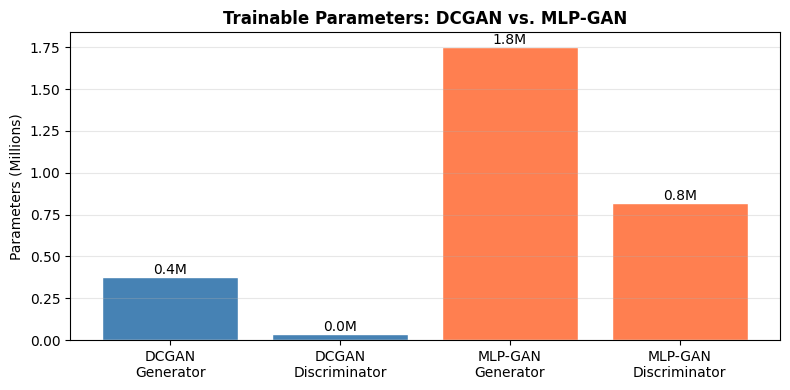

In [12]:
def count_params(model):
    return sum(np.prod(v.shape) for v in model.trainable_variables)

print('=== Parameter Count ===')
print(f'DCGAN   Generator:     {count_params(dcgan_generator):>12,}')
print(f'DCGAN   Discriminator: {count_params(dcgan_discriminator):>12,}')
print(f'MLP-GAN Generator:     {count_params(mlp_generator):>12,}')
print(f'MLP-GAN Discriminator: {count_params(mlp_discriminator):>12,}')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
models = ['DCGAN\nGenerator', 'DCGAN\nDiscriminator', 'MLP-GAN\nGenerator', 'MLP-GAN\nDiscriminator']
params = [
    count_params(dcgan_generator) / 1e6,
    count_params(dcgan_discriminator) / 1e6,
    count_params(mlp_generator) / 1e6,
    count_params(mlp_discriminator) / 1e6,
]
colors = ['steelblue', 'steelblue', 'coral', 'coral']
bars = ax.bar(models, params, color=colors, edgecolor='white')
ax.bar_label(bars, labels=[f'{p:.1f}M' for p in params], fontsize=10)
ax.set_ylabel('Parameters (Millions)')
ax.set_title('Trainable Parameters: DCGAN vs. MLP-GAN', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('gan_parameter_comparison.png', dpi=100, bbox_inches='tight')
plt.show()